# 葡萄酒质量预测：EDA、分组验证与传统机器学习

这是供 Squarepoint QR 面试练习使用的公开数据项目，**未确认它就是实际面试原题**。采用 UCI **Wine Quality** 红酒与白酒数据：11 个理化指标预测质量评分 `quality`。它没有时间戳，属于横截面表格数据，**不是时间序列**；也不同于 `sklearn.datasets.load_wine()` 的葡萄酒品种分类数据。

本 notebook 重点：先检查数据，再开展 EDA；通过分组切分阻止相同特征样本进入不同数据集；在训练集交叉验证比较 6 种方法，最后只对预先选定模型做留出测试。所有方法均为非深度学习方法。

**预测任务**：利用样品的理化测量和红/白酒类型预测人工质量评分。评分是有序离散变量，本练习将其作为回归目标；主要指标为 MAE，RMSE 和 R² 为补充。模型输出保留连续值，避免靠随意四舍五入或截断改善指标。

**数据来源**：[UCI Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)，Cortez et al. (2009)，CC BY 4.0。


## 0. 运行方式与实验规则

建议 Python 3.10+，在 Jupyter 中依次执行所有单元格。首次运行自动下载两份 CSV 到当前目录的 `data/`，之后使用缓存。若环境缺少依赖，可先运行下方注释中的 `%pip install` 命令；安装后必要时重启内核。

1. 先确定留出集，后续 EDA 和选模型只使用训练集。
2. 同一组理化特征与酒类型必须落在同一个 split/fold 中，即使评分不同也不拆开。
3. 缺失值填补、标准化、类别编码均在 Pipeline 内拟合。
4. 以训练集的分组交叉验证 MAE 选模型，测试集仅用于最终一次评估与误差解释。

六种模型：中位数基线、Ridge、Elastic Net、RBF-SVR、随机森林、直方图梯度提升树。运行时间随电脑不同，通常需要数分钟；未进行大规模参数搜索。


In [1]:
# 首次使用且缺少依赖时，取消下一行注释并执行，然后按需要重启内核。
# %pip install "numpy>=1.26,<3" "pandas>=2.1,<4" "matplotlib>=3.8,<4" "scikit-learn>=1.4,<2" "ipykernel>=6,<8"

from pathlib import Path
from urllib.request import Request, urlopen
from importlib.metadata import version
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

SEED = 42
N_JOBS = 2
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.2})

display(pd.Series({p: version(p) for p in ["numpy", "pandas", "matplotlib", "scikit-learn"]}, name="version"))


numpy            2.5.3
pandas           3.0.6
matplotlib      3.11.2
scikit-learn     1.9.1
Name: version, dtype: str

## 1. 下载与结构检查

原始红酒 1,599 行、白酒 4,898 行，合计 6,497 行。两份文件以分号分隔。这里只做格式、缺失、重复等基础审计；目标分布和特征关系放到训练集上观察。

重复行未必是错误，可能来自重复测量。直接删掉它们会改变数据权重；这里保留记录，但把相同输入的样本视为一组，从而避免近似“背答案”的评估。


In [2]:
BASE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality"
NUMERIC_FEATURES = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol",
]
FEATURES = NUMERIC_FEATURES + ["wine_type"]
TARGET = "quality"


def load_wine(wine_type):
    # 首次下载并缓存；读入后立即验证字段，避免将错误页面当成数据。
    path = DATA_DIR / f"winequality-{wine_type}.csv"
    if not path.exists():
        request = Request(f"{BASE_URL}/{path.name}", headers={"User-Agent": "WineQualityNotebook/1.0"})
        with urlopen(request, timeout=60) as response:
            content = response.read()
        # 临时文件写完再重命名，防止下载中断留下看起来存在的半个 CSV。
        temporary_path = path.with_suffix(".download")
        temporary_path.write_bytes(content)
        temporary_path.replace(path)
    frame = pd.read_csv(path, sep=";")
    assert set(frame.columns) == set(NUMERIC_FEATURES + [TARGET]), "字段不符合 UCI Wine Quality 格式"
    frame["wine_type"] = wine_type
    return frame


data = pd.concat([load_wine("red"), load_wine("white")], ignore_index=True)
assert len(data) == 6497, "公开原始数据的行数应为 6497；请确认下载内容或本地缓存"
assert data[TARGET].notna().all(), "标签缺失需要单独处理，不能填补标签"
assert data[TARGET].between(0, 10).all()
assert np.equal(data[TARGET], np.floor(data[TARGET])).all(), "原始评分应为整数"

audit = pd.DataFrame({"dtype": data.dtypes.astype(str), "missing": data.isna().sum()})
display(audit)
print(f"样本数：{len(data):,}；输入特征数：{len(FEATURES)}（含酒类型）")
print(f"完整重复记录数：{data.duplicated().sum():,}")
print(f"输入特征重复记录数：{data.duplicated(subset=FEATURES).sum():,}")


,dtype,missing
fixed acidity,float64,0
volatile acidity,float64,0
citric acid,float64,0
residual sugar,float64,0
chlorides,float64,0
free sulfur dioxide,float64,0
total sulfur dioxide,float64,0
density,float64,0
pH,float64,0
sulphates,float64,0


样本数：6,497；输入特征数：12（含酒类型）
完整重复记录数：1,177
输入特征重复记录数：1,177


## 2. 先按输入分组，再划分训练集与测试集

分组键包含全部 11 个理化指标和 `wine_type`，**不包含目标 `quality`**。这是因为完全相同的输入可能对应不同的人工评分，依然不应跨集合。

`GroupShuffleSplit(test_size=0.2)` 按组抽取约 20% 的组作为测试集，所以实际样本比例可能略偏离 20%。本实验不根据测试分数挑选种子。分组只能控制精确相同的输入；若实际任务提供生产批次、酒庄或重复测量 ID，应优先用这些业务分组。


In [3]:
X_all = data[FEATURES].copy()
y_all = data[TARGET].astype(float)

# 用 MultiIndex 的完全相等关系分组，而不是把特征四舍五入后人为合并近邻。
# factorize 返回每种不同输入组合的整数编号；质量分数不参与编号。
groups_all = pd.factorize(pd.MultiIndex.from_frame(X_all), sort=False)[0]
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(splitter.split(X_all, y_all, groups=groups_all))

X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
y_train, y_test = y_all.iloc[train_idx].copy(), y_all.iloc[test_idx].copy()
groups_train, groups_test = groups_all[train_idx], groups_all[test_idx]

assert not set(groups_train).intersection(groups_test), "同一输入组合不能同时出现在训练和测试集"
assert len(train_idx) + len(test_idx) == len(data)
train_eda = X_train.assign(quality=y_train)

display(pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(X_train), len(X_test)],
    "unique_input_groups": [len(np.unique(groups_train)), len(np.unique(groups_test))],
}).set_index("split"))
print("后续 EDA 只使用 train_eda；测试标签保留到最终评估。")


,rows,unique_input_groups
split,,
train,5210,4256
test,1287,1064


后续 EDA 只使用 train_eda；测试标签保留到最终评估。


## 3. EDA：标签不均衡、酒类型差异、尺度与异常值

先看评分范围与各类样本量，再比较红白酒。质量评分的极端等级较少，这会影响 MAE 的解释：总 MAE 很好，也可能仍无法辨别稀有的高分酒。

下方所有图都使用训练数据。图中的英文轴标签用于避免不同电脑上的中文字体兼容问题；分析说明保留中文。


,count,mean,std,min,25%,50%,75%,max
fixed acidity,5210.0,7.203,1.298,3.800,6.400,7.000,7.700,15.900
volatile acidity,5210.0,0.339,0.164,0.080,0.230,0.290,0.400,1.580
citric acid,5210.0,0.318,0.146,0.000,0.250,0.310,0.390,1.660
residual sugar,5210.0,5.463,4.786,0.600,1.800,3.000,8.100,65.800
chlorides,5210.0,0.055,0.032,0.009,0.038,0.047,0.064,0.611
free sulfur dioxide,5210.0,30.688,17.998,1.000,17.000,29.000,41.500,289.000
total sulfur dioxide,5210.0,116.330,56.688,6.000,78.000,118.000,157.000,440.000
density,5210.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039
pH,5210.0,3.219,0.162,2.720,3.110,3.200,3.320,4.010
sulphates,5210.0,0.528,0.143,0.220,0.430,0.500,0.600,1.980


,count,mean,std,min,max
wine_type,,,,,
red,1263,5.627,0.812,3.0,8.0
white,3947,5.874,0.891,3.0,9.0


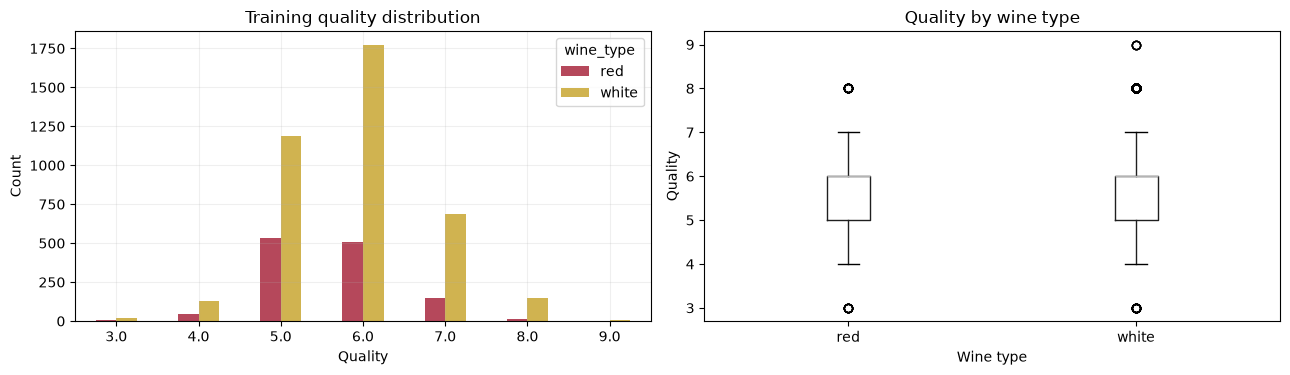

样本最多的两个评分及训练占比：


,proportion
quality,
6.0,0.437620
5.0,0.329942


In [4]:
display(train_eda[NUMERIC_FEATURES + [TARGET]].describe().T.round(3))
display(train_eda.groupby("wine_type")[TARGET].agg(["count", "mean", "std", "min", "max"]).round(3))

quality_counts = pd.crosstab(train_eda[TARGET], train_eda["wine_type"]).reindex(columns=["red", "white"], fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
quality_counts.plot.bar(ax=axes[0], color=["#b5485b", "#d0b350"], rot=0)
axes[0].set(title="Training quality distribution", xlabel="Quality", ylabel="Count")
train_eda.boxplot(column=TARGET, by="wine_type", ax=axes[1], grid=False)
axes[1].set(title="Quality by wine type", xlabel="Wine type", ylabel="Quality")
fig.suptitle("")
plt.tight_layout()
plt.show()

# 自动生成基于本次训练切分的描述，避免把一次运行的观察硬写成永远成立的结论。
largest_scores = y_train.value_counts(normalize=True).head(2)
print("样本最多的两个评分及训练占比：")
display(largest_scores.rename("proportion").to_frame())


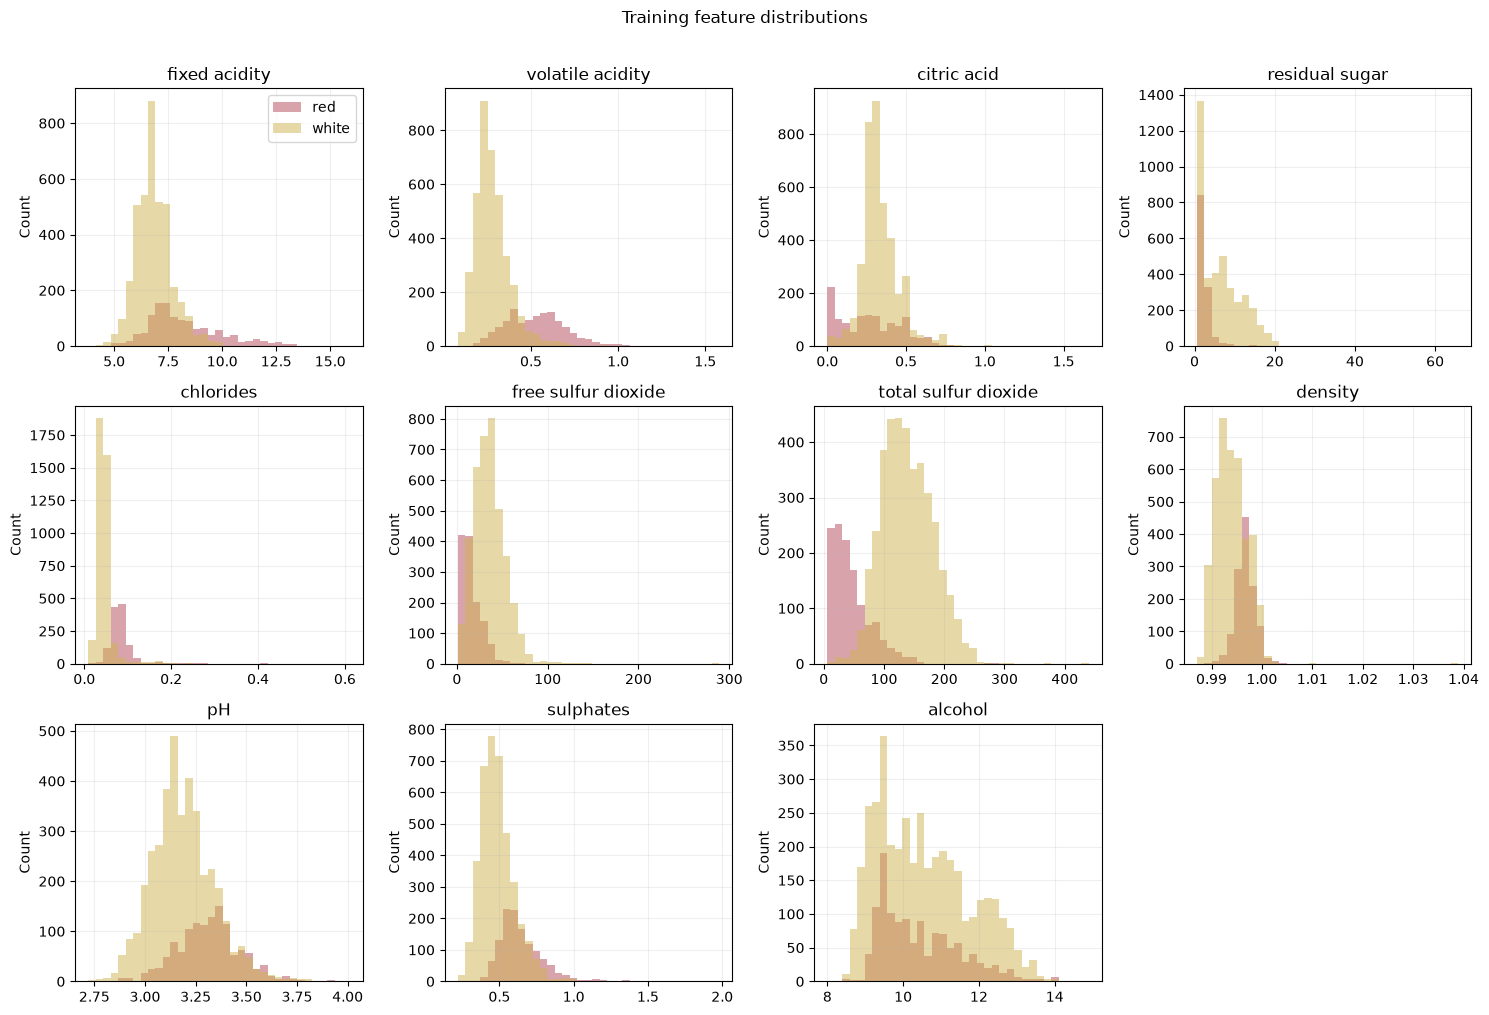

,IQR_tail_fraction
citric acid,0.079
volatile acidity,0.058
fixed acidity,0.054
chlorides,0.044
sulphates,0.027
residual sugar,0.019
pH,0.012
free sulfur dioxide,0.010
total sulfur dioxide,0.001
density,0.001


In [5]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
for feature, ax in zip(NUMERIC_FEATURES, axes.ravel()):
    # density=False 展示样本数量；红白酒样本数不同，不能只靠高度判断分布差异。
    # 两种酒使用相同的分箱边界，让同一横坐标区间的柱高可以直接比较。
    bin_edges = np.histogram_bin_edges(train_eda[feature].dropna(), bins=35)
    for wine_type, color in [("red", "#b5485b"), ("white", "#d0b350")]:
        values = train_eda.loc[train_eda["wine_type"].eq(wine_type), feature]
        ax.hist(values, bins=bin_edges, alpha=0.5, color=color, label=wine_type)
    ax.set(title=feature, ylabel="Count")
axes.ravel()[-1].axis("off")
axes[0, 0].legend()
fig.suptitle("Training feature distributions", y=1.01)
plt.tight_layout()
plt.show()

# IQR 规则只标记尾部观测。化学指标偏态很常见，不能直接把这些观测删掉。
q1 = X_train[NUMERIC_FEATURES].quantile(0.25)
q3 = X_train[NUMERIC_FEATURES].quantile(0.75)
iqr = q3 - q1
tail_flags = X_train[NUMERIC_FEATURES].lt(q1 - 1.5 * iqr) | X_train[NUMERIC_FEATURES].gt(q3 + 1.5 * iqr)
display(tail_flags.mean().sort_values(ascending=False).rename("IQR_tail_fraction").to_frame().round(3))


特征之间的量纲不同，线性正则化模型和 SVR 需要标准化。树模型不依赖这种尺度处理。相关系数只描述边际关系，并不证明因果关系，也不保证模型中的条件影响方向相同。

红白酒的组成可能不同，因此既看合并相关矩阵，也看各酒类型内与评分的相关性。若两个类型混合后的关系与组内关系不同，不能简单下结论说某个指标“导致”高质量。


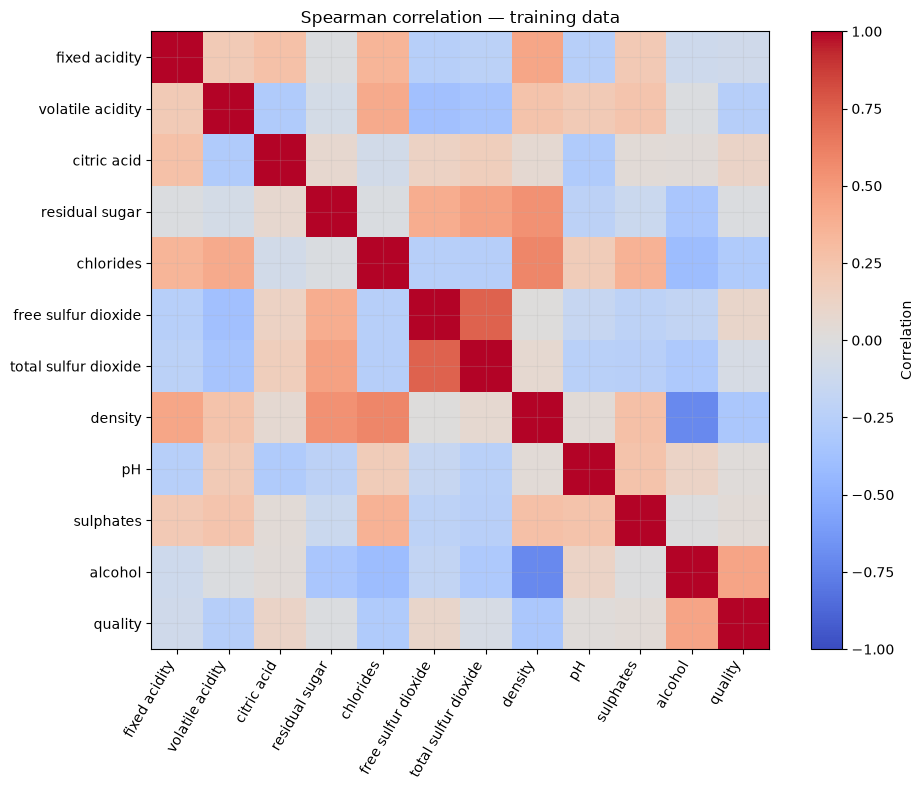

,red,white
alcohol,0.466,0.436
pH,-0.049,0.096
sulphates,0.381,0.038
citric acid,0.206,0.030
free sulfur dioxide,-0.010,0.027
fixed acidity,0.102,-0.079
residual sugar,0.071,-0.085
total sulfur dioxide,-0.157,-0.202
volatile acidity,-0.377,-0.204
chlorides,-0.177,-0.312


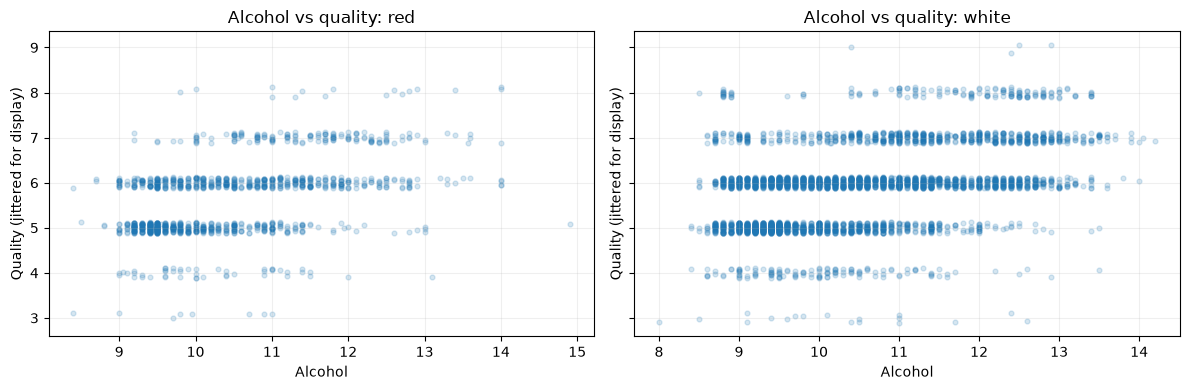

In [6]:
# Spearman 相关系数对单调但非线性的关系更敏感，且比 Pearson 更少受尾部值支配。
correlation = train_eda[NUMERIC_FEATURES + [TARGET]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation)), correlation.columns, rotation=60, ha="right")
ax.set_yticks(range(len(correlation)), correlation.columns)
ax.set_title("Spearman correlation — training data")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

by_type_corr = pd.DataFrame({
    wine_type: group[NUMERIC_FEATURES + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET)
    for wine_type, group in train_eda.groupby("wine_type")
})
display(by_type_corr.sort_values("white", ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
rng = np.random.default_rng(SEED)
for ax, wine_type in zip(axes, ["red", "white"]):
    subset = train_eda[train_eda["wine_type"].eq(wine_type)]
    # 少量纵向抖动只用于展示重叠散点，绝不修改训练标签。
    jitter = rng.uniform(-0.12, 0.12, size=len(subset))
    ax.scatter(subset["alcohol"], subset[TARGET] + jitter, alpha=0.18, s=12)
    ax.set(title=f"Alcohol vs quality: {wine_type}", xlabel="Alcohol", ylabel="Quality (jittered for display)")
plt.tight_layout()
plt.show()


## 4. 预处理与模型

**中位数基线**忽略特征，只预测训练评分的中位数，是 MAE 对应的自然常数基线。Ridge 和 Elastic Net 是不同正则化的线性模型；RBF-SVR 建模非线性关系；随机森林通过多棵树降低方差；梯度提升树逐步拟合残差。

下面的参数是预先设定的合理起点。模型比较本身已经是一种选择，因此比较全部发生在训练集的 4 折 GroupKFold 中。若后续要调参，可在相同训练组上做小规模 `GridSearchCV`，并保持测试集封存。当前版本不在测试结果出来后增加候选模型。

即使原始数据没有缺失，也保留填补器，便于真实面试数据中存在少量缺失时复用。线性模型/SVR 使用标准化，树模型保持原始数值尺度。`wine_type` 通过 one-hot 编码输入模型。


In [7]:
def make_preprocessor(scale_numeric):
    # 每个模型拥有独立预处理器，避免不同实验意外共享已拟合状态。
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))

    category_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), NUMERIC_FEATURES),
        ("type", category_pipeline, ["wine_type"]),
    ], remainder="drop")


model_specs = {
    "Dummy median": (DummyRegressor(strategy="median"), False),
    "Ridge": (Ridge(alpha=10.0), True),
    "Elastic Net": (ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=20000, random_state=SEED), True),
    "RBF-SVR": (SVR(C=8.0, epsilon=0.15, gamma="scale"), True),
    "Random Forest": (RandomForestRegressor(
        n_estimators=160, min_samples_leaf=2, max_features=0.8,
        random_state=SEED, n_jobs=N_JOBS,
    ), False),
    "Hist Gradient Boosting": (HistGradientBoostingRegressor(
        max_iter=180, learning_rate=0.06, max_leaf_nodes=15,
        l2_regularization=2.0, early_stopping=False, random_state=SEED,
    ), False),
}

models = {
    name: Pipeline([("preprocess", make_preprocessor(scale)), ("model", estimator)])
    for name, (estimator, scale) in model_specs.items()
}

# 提前固定 CV 的分组规则。先验证每一折的组完全不重叠，再开始任何模型训练。
cv = GroupKFold(n_splits=4)
for fold_train, fold_valid in cv.split(X_train, y_train, groups_train):
    assert not set(groups_train[fold_train]).intersection(groups_train[fold_valid])
print(f"候选模型：{list(models)}")


候选模型：['Dummy median', 'Ridge', 'Elastic Net', 'RBF-SVR', 'Random Forest', 'Hist Gradient Boosting']


完成 Dummy median             | CV MAE=0.6397
完成 Ridge                    | CV MAE=0.5722
完成 Elastic Net              | CV MAE=0.5732


完成 RBF-SVR                  | CV MAE=0.5454


完成 Random Forest            | CV MAE=0.5322


完成 Hist Gradient Boosting   | CV MAE=0.5452


,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean,elapsed_seconds
model,,,,,
Random Forest,0.5322,0.0243,0.6908,0.3803,2.3394
Hist Gradient Boosting,0.5452,0.0209,0.6997,0.3643,0.3457
RBF-SVR,0.5454,0.0190,0.7118,0.3418,1.6520
Ridge,0.5722,0.0230,0.7403,0.2883,0.0311
Elastic Net,0.5732,0.0239,0.7414,0.2862,0.0315
Dummy median,0.6397,0.0101,0.8977,-0.0466,0.0336


按训练集 CV MAE 选中的模型：Random Forest


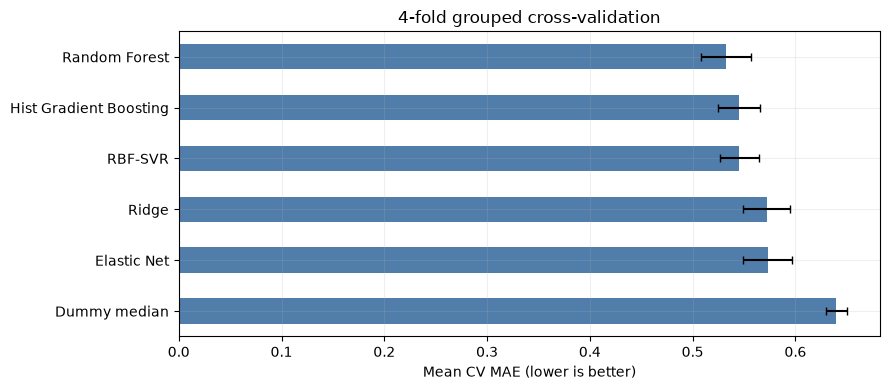

In [8]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}
cv_rows = []
fold_rows = []

for name, pipeline in models.items():
    start = perf_counter()
    # CV 过程每折都会 clone 并拟合整个 Pipeline；验证折不会参与填补/标准化参数估计。
    # 外层串行、森林内部至多使用两个进程/线程，避免嵌套并行拖慢机器。
    scores = cross_validate(
        pipeline, X_train, y_train, groups=groups_train,
        cv=cv, scoring=scoring, n_jobs=1, error_score="raise",
    )
    # sklearn 为统一“越大越好”返回负误差；转换回正数才是通常定义的 MAE/RMSE。
    fold_mae = -scores["test_MAE"]
    cv_rows.append({
        "model": name,
        "CV_MAE_mean": fold_mae.mean(),
        "CV_MAE_std": fold_mae.std(ddof=1),
        "CV_RMSE_mean": (-scores["test_RMSE"]).mean(),
        "CV_R2_mean": scores["test_R2"].mean(),
        "elapsed_seconds": perf_counter() - start,
    })
    for fold_id, value in enumerate(fold_mae, start=1):
        fold_rows.append({"model": name, "fold": fold_id, "MAE": value})
    print(f"完成 {name:24s} | CV MAE={fold_mae.mean():.4f}")

cv_results = pd.DataFrame(cv_rows).set_index("model").sort_values("CV_MAE_mean")
cv_fold_results = pd.DataFrame(fold_rows)
display(cv_results.round(4))

# 选择规则在接触测试标签前执行；若基线最好，也允许基线赢得比较。
best_name = cv_results.index[0]
print(f"按训练集 CV MAE 选中的模型：{best_name}")

ax = cv_results.sort_values("CV_MAE_mean", ascending=False)["CV_MAE_mean"].plot.barh(
    xerr=cv_results.sort_values("CV_MAE_mean", ascending=False)["CV_MAE_std"],
    color="#507daa", capsize=3, figsize=(9, 4),
)
ax.set(xlabel="Mean CV MAE (lower is better)", ylabel="", title="4-fold grouped cross-validation")
plt.tight_layout()
plt.show()


交叉验证的标准差描述这 4 个折之间的波动，**不是严格的置信区间**。模型间差异很小时，可以结合训练时间、稳定性和解释性讨论取舍，而不是把微小分差当成必然提升。

## 5. 冻结选择并进行一次留出测试

现在用全部训练数据重新拟合选定模型，同时拟合中位数基线。只比较这两者在测试集上的表现；测试结果不用于重新选择参数或模型。若之后需要继续研究，应建立新的独立验证方案，而不是反复追逐当前测试分数。


In [9]:
def regression_metrics(actual, prediction):
    return {
        "MAE": mean_absolute_error(actual, prediction),
        "RMSE": np.sqrt(mean_squared_error(actual, prediction)),
        "R2": r2_score(actual, prediction),
    }


selected_model = clone(models[best_name]).fit(X_train, y_train)
baseline_model = clone(models["Dummy median"]).fit(X_train, y_train)
test_prediction = selected_model.predict(X_test)
baseline_prediction = baseline_model.predict(X_test)
assert len(test_prediction) == len(y_test)
assert np.isfinite(test_prediction).all()

test_results = pd.DataFrame([
    {"evaluation": "Selected by train CV", "model": best_name, **regression_metrics(y_test, test_prediction)},
    {"evaluation": "Reference baseline", "model": "Dummy median", **regression_metrics(y_test, baseline_prediction)},
]).set_index("evaluation")
display(test_results.round(4))

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
selected_mae = mean_absolute_error(y_test, test_prediction)
if baseline_mae > 0:
    print(f"相对于中位数基线的测试 MAE 改善：{1 - selected_mae / baseline_mae:.1%}")
print("注意：这是当前分组切分下的效果，不等于对新产区、新年份酒样的外推能力。")


,model,MAE,RMSE,R2
evaluation,,,,
Selected by train CV,Random Forest,0.5043,0.6533,0.4122
Reference baseline,Dummy median,0.6270,0.8677,-0.0370


相对于中位数基线的测试 MAE 改善：19.6%
注意：这是当前分组切分下的效果，不等于对新产区、新年份酒样的外推能力。


## 6. 误差诊断：回归到均值、稀有评分与红白酒表现

残差定义为 `实际值 − 预测值`：正残差表示低估，负残差表示高估。高分酒被低估、低分酒被高估，是标签不均衡和评分噪声共同作用下常见的现象，需要通过图和分组指标核实。

下面是**最终模型的事后解释**。不要根据测试集上的某个分组表现，继续修改模型再汇报同一个测试集分数。分组样本数很小时，单个 MAE 可能不稳定。


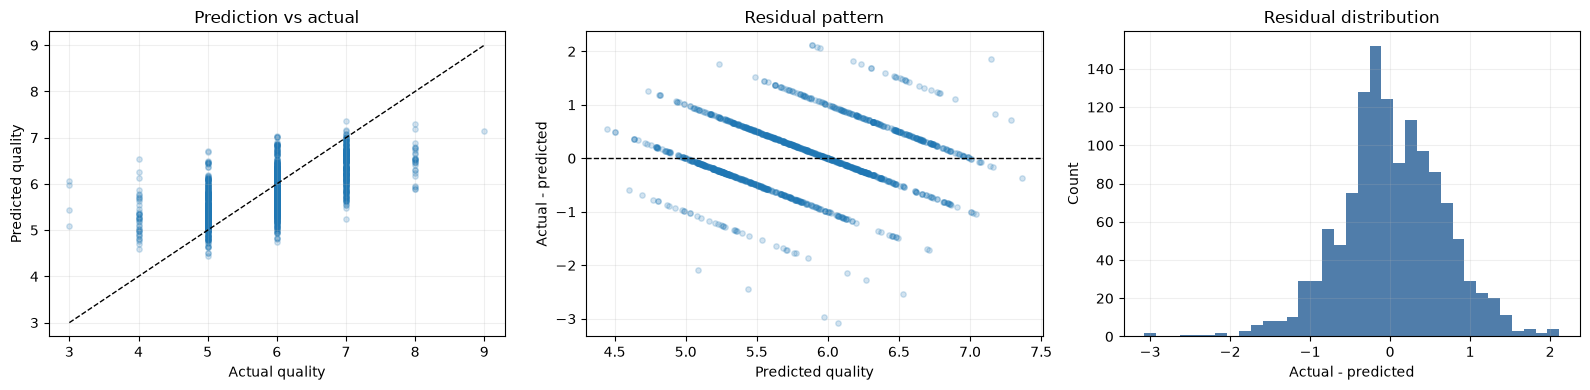

,count,actual_mean,predicted_mean,MAE,mean_residual
wine_type,,,,,
red,336,5.670,5.647,0.470,0.022
white,951,5.895,5.870,0.516,0.025


,count,actual_mean,predicted_mean,MAE,mean_residual
actual,,,,,
3.0,4,3.0,5.642,2.642,-2.642
4.0,39,4.0,5.309,1.309,-1.309
5.0,419,5.0,5.411,0.446,-0.411
6.0,556,6.0,5.873,0.367,0.127
7.0,241,7.0,6.367,0.641,0.633
8.0,27,8.0,6.498,1.502,1.502
9.0,1,9.0,7.145,1.855,1.855


预测与实际评分相差不超过 1 分的比例：88.3%
±1 分命中比例只作为辅助解释；最终选择仍依据连续输出的 MAE。


In [10]:
diagnostics = X_test[["wine_type"]].copy()
diagnostics["actual"] = y_test
diagnostics["predicted"] = test_prediction
diagnostics["residual"] = diagnostics["actual"] - diagnostics["predicted"]
diagnostics["absolute_error"] = diagnostics["residual"].abs()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(diagnostics["actual"], diagnostics["predicted"], alpha=0.2, s=15)
lower = min(diagnostics["actual"].min(), diagnostics["predicted"].min())
upper = max(diagnostics["actual"].max(), diagnostics["predicted"].max())
axes[0].plot([lower, upper], [lower, upper], "k--", linewidth=1)
axes[0].set(xlabel="Actual quality", ylabel="Predicted quality", title="Prediction vs actual")
axes[1].scatter(diagnostics["predicted"], diagnostics["residual"], alpha=0.2, s=15)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(xlabel="Predicted quality", ylabel="Actual - predicted", title="Residual pattern")
axes[2].hist(diagnostics["residual"], bins=35, color="#507daa")
axes[2].set(xlabel="Actual - predicted", ylabel="Count", title="Residual distribution")
plt.tight_layout()
plt.show()


def grouped_errors(frame, by):
    # 同时给出样本数和平均有符号误差，避免只看 MAE 忽略系统性偏高/偏低。
    return frame.groupby(by).agg(
        count=("actual", "size"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
    )


display(grouped_errors(diagnostics, "wine_type").round(3))
display(grouped_errors(diagnostics, "actual").round(3))
print(f"预测与实际评分相差不超过 1 分的比例：{diagnostics['absolute_error'].le(1).mean():.1%}")
print("±1 分命中比例只作为辅助解释；最终选择仍依据连续输出的 MAE。")


## 7. 统一的模型解释：置换重要性

在模型固定后，随机打乱测试集中的一列，并观察 MAE 恶化多少。这可以对不同模型使用相同解释方式，并且直接对应原始输入特征。

这里使用至多 800 个测试样本、每列重复 5 次以控制运行时间。数值表示对当前模型预测的贡献，**不是因果效应**。高度相关的变量可能互相替代，因此单列重要性偏低并不代表变量在业务上没有意义；重要性偶尔为负也可能来自采样波动。


,MAE_increase_mean,repeat_std
feature,,
alcohol,0.1711,0.0099
volatile acidity,0.0662,0.0076
free sulfur dioxide,0.0307,0.0052
sulphates,0.0236,0.0072
total sulfur dioxide,0.0169,0.0032
chlorides,0.0161,0.0019
residual sugar,0.0144,0.0023
citric acid,0.0129,0.0020
density,0.0109,0.0036


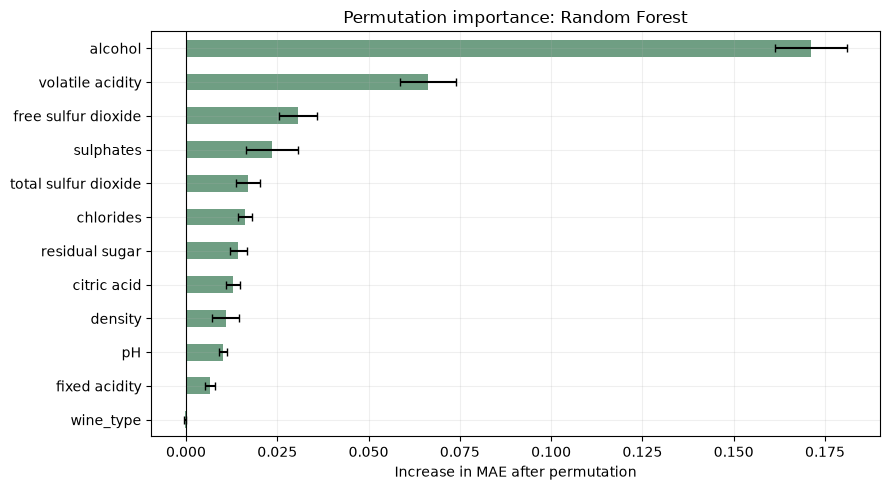

In [11]:
# scoring 是负 MAE，因此“打乱前得分 − 打乱后得分”恰好等于 MAE 的增加量。
# n_jobs=1 避免置换层和随机森林内部的并行叠加。
# 先固定同一批解释样本，让打乱前后的 MAE 严格基于相同样本进行比较。
importance_index = X_test.sample(n=min(800, len(X_test)), random_state=SEED).index
X_importance = X_test.loc[importance_index]
y_importance = y_test.loc[importance_index]
importance = permutation_importance(
    selected_model, X_importance, y_importance,
    scoring="neg_mean_absolute_error", n_repeats=5,
    random_state=SEED, n_jobs=1, max_samples=1.0,
)
importance_table = pd.DataFrame({
    "feature": FEATURES,
    "MAE_increase_mean": importance.importances_mean,
    "repeat_std": importance.importances_std,
}).set_index("feature").sort_values("MAE_increase_mean")
display(importance_table.sort_values("MAE_increase_mean", ascending=False).round(4))

ax = importance_table["MAE_increase_mean"].plot.barh(
    xerr=importance_table["repeat_std"], color="#6f9e83", capsize=3, figsize=(9, 5),
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(xlabel="Increase in MAE after permutation", ylabel="", title=f"Permutation importance: {best_name}")
plt.tight_layout()
plt.show()


## 8. 可复用的预测与面试复盘

拟合后的 Pipeline 接收原始 DataFrame，因此新样本不需要自己计算标准化参数或类别编码。必须保留训练时的列名和单位，且 `wine_type` 应为 `red` 或 `white`。

下面只是将当前测试样本当作输入格式示例，输出真实的模型预测，**不代表另一个独立测试集**。


In [12]:
example_input = X_test.head(5).copy()
example_output = example_input.assign(predicted_quality=selected_model.predict(example_input))
display(example_output.round(3))

# 将关键数字组合成可直接填入项目汇报的简短结果，不把单次运行结论写死。
print(f"数据：{len(data):,} 条；训练 {len(X_train):,} 条；测试 {len(X_test):,} 条。")
print(f"选模：4 折按输入分组 CV；最佳模型为 {best_name}。")
print(f"训练 CV MAE：{cv_results.loc[best_name, 'CV_MAE_mean']:.4f}。")
print(f"最终测试 MAE：{selected_mae:.4f}；基线 MAE：{baseline_mae:.4f}。")


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type,predicted_quality
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.998,3.35,0.80,10.5,red,5.451
11,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.998,3.35,0.80,10.5,red,5.451
14,8.9,0.62,0.18,3.8,0.176,52.0,145.0,0.999,3.16,0.88,9.2,red,4.984
17,8.1,0.56,0.28,1.7,0.368,16.0,56.0,0.997,3.11,1.28,9.3,red,5.208
19,7.9,0.32,0.51,1.8,0.341,17.0,56.0,0.997,3.04,1.08,9.2,red,5.337


数据：6,497 条；训练 5,210 条；测试 1,287 条。
选模：4 折按输入分组 CV；最佳模型为 Random Forest。
训练 CV MAE：0.5322。
最终测试 MAE：0.5043；基线 MAE：0.6270。


### 面试中应能解释的取舍

- **为什么不是时序？** 没有时间索引，也没有未来预测窗口；样本单位是一瓶/一次酒样测量。真实任务若新增年份、批次或酒庄信息，切分方式可能改变。
- **为什么按输入分组？** 防止相同理化测量出现在训练和验证两边，夸大记忆能力。对于精确重复以外的相关样本，本数据没有足够 ID 完全控制。
- **为什么先用回归？** 评分存在顺序与距离信息，MAE 易解释；将它当连续值是一种建模近似。若业务要求准确等级概率，可另设有序分类任务并在训练集验证。
- **为什么线性模型也值得做？** 它能提供快速、稳定、可解释的参照。非线性方法只有在可靠验证下取得改善才值得增加复杂度。
- **为什么没有删掉所有异常值？** 偏态和少数高浓度样本未必是脏数据。需要仪器范围、单位或业务规则支持，才有理由修正或删除。
- **有什么局限？** 人工评分存在噪声；少数评分样本稀少；相同输入分组不等于独立生产批次；公开数据上的表现不保证跨产区泛化。
- **若只有 6 小时如何安排？** 先用约 1 小时明确任务、检查并切分数据；约 1 小时完成重点 EDA；约 2 小时基线与少量模型；剩余时间用于误差诊断、验证检查和汇报。不要在画图细节上耗尽建模时间。

后续扩展应先重设研究方案再实验：例如按生产批次划分、训练集内部小规模调参、误差的组级 bootstrap、序数分类，或检验不同类型分别建模。当前 notebook 不包含深度学习。
